PRÁCTICA 2. ANÁLISI ESTADISTICO DE SEÑALES

In [2]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

Carga del archivo .mat

In [3]:
mat_data=sio.loadmat('signals.mat')
print("llavez encontradas en el archivo",[key for key in mat_data.keys() if not key.startswith('__')])

llavez encontradas en el archivo ['Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2']


1.A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las señales, cree un vector de tiempo. 

In [4]:
fs=1024 #Frecuencia de muestreo
#Extraer señales
sin_filtrar=mat_data['ECG_asRecording'].squeeze()
filtrada=mat_data['ECG_filtered'].squeeze()

#Número total de muestras
n_muestras=len(sin_filtrar)

#Crear el vector de tiempo
tiempo=np.arange(n_muestras)/fs

print(f"Número de muestras: {n_muestras}")
print(f"Duración total del registro: {n_muestras/fs:.2f} segundos")


Número de muestras: 30720
Duración total del registro: 30.00 segundos


2.Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.

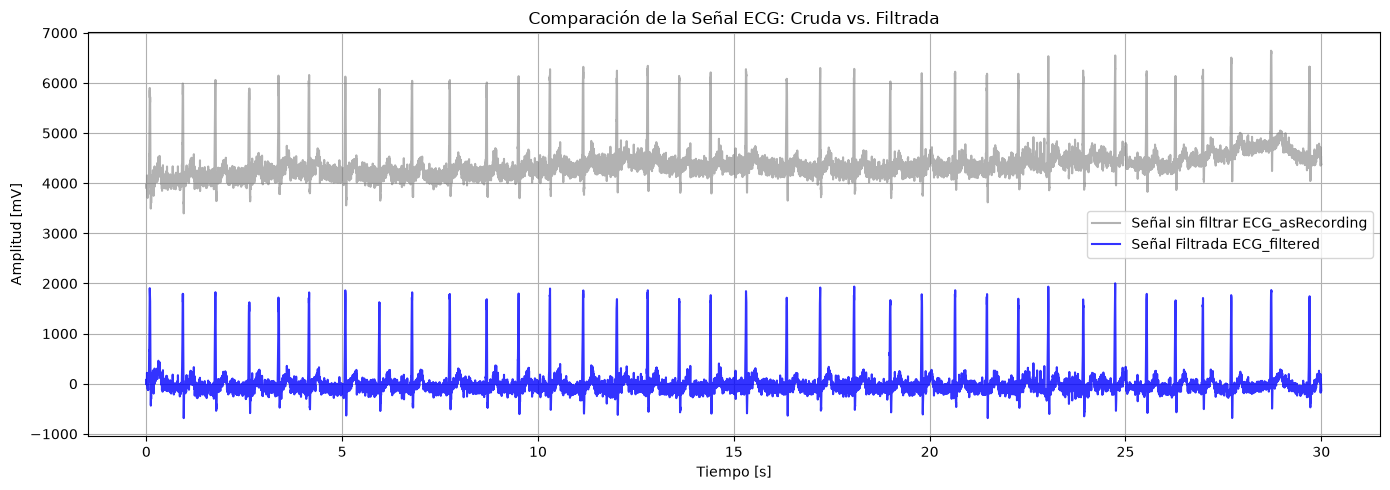

In [5]:
plt.figure(figsize=(14,5))
plt.plot(tiempo,sin_filtrar,label='Señal sin filtrar ECG_asRecording', alpha=0.6,color='gray')
plt.plot(tiempo,filtrada, label='Señal Filtrada ECG_filtered', alpha=0.8, color='blue')
plt.title('Comparación de la Señal ECG: Cruda vs. Filtrada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

3.Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.

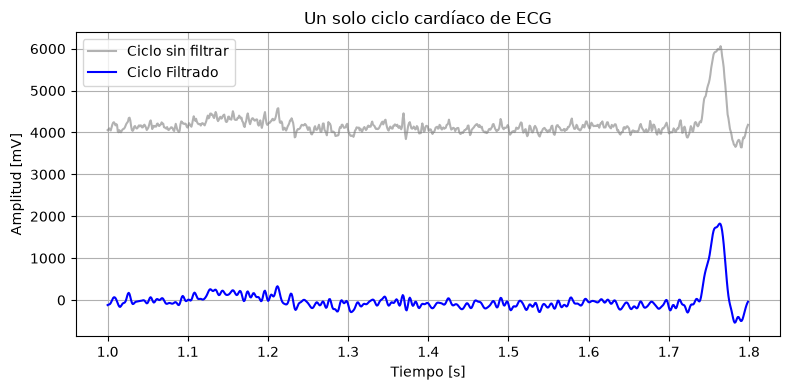

ESTADÍSTICOS CICLO SIN FILTRAR
Media: 4180.9677
Varianza: 89522.2342
Desviación Estándar: 299.2027
RMS: 4191.6599

ESTADÍSTICOS CICLO FILTRADO
Media: -9.5482
Varianza: 87970.0260
Desviación Estándar: 296.5974
RMS: 296.7511


In [6]:
#Función para calcular el  RSM
def calcular_rsm(signal):
    return np.sqrt(np.mean(signal**2))

#Selección de un solo ciclo cardíaco (ventana entre t=1.0s y t=1.8s)
t_inicio,t_fin=1.0,1.8
idx_inicio,idx_fin= int(t_inicio*fs),int(t_fin*fs)

ciclo_sinfiltrar= sin_filtrar[idx_inicio:idx_fin]
ciclo_filtrada= filtrada[idx_inicio:idx_fin]
tiempo_ciclo= tiempo[idx_inicio:idx_fin]

#Graficar el ciclo aislado
plt.figure(figsize=(8,4))
plt.plot(tiempo_ciclo,ciclo_sinfiltrar,label='Ciclo sin filtrar',color= 'gray',alpha=0.6)
plt.plot (tiempo_ciclo, ciclo_filtrada,label='Ciclo Filtrado', color='blue')
plt.title('Un solo ciclo cardíaco de ECG')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#Impresión en consola de metricas estadisticas del ciclo 
print("ESTADÍSTICOS CICLO SIN FILTRAR")
print(f"Media: {np.mean(ciclo_sinfiltrar):.4f}")
print(f"Varianza: {np.var(ciclo_sinfiltrar):.4f}")
print(f"Desviación Estándar: {np.std(ciclo_sinfiltrar):.4f}")
print(f"RMS: {calcular_rsm(ciclo_sinfiltrar):.4f}")

print("\nESTADÍSTICOS CICLO FILTRADO")
print(f"Media: {np.mean(ciclo_filtrada):.4f}")
print(f"Varianza: {np.var(ciclo_filtrada):.4f}")
print(f"Desviación Estándar: {np.std(ciclo_filtrada):.4f}")
print(f"RMS: {calcular_rsm(ciclo_filtrada):.4f}")

**Análisis:** El ciclo sin filtrar tiene un promedio muy alto (4180.97) porque la señal trae un desplazamiento fijo propio del equipo, no del corazón; por eso su RMS (4191.66) sale casi igual al promedio, ya que ese desplazamiento opaca la variación real. Al filtrar, el promedio cae a casi cero (-9.55), lo que confirma que ese desplazamiento se elimina, mientras que la varianza y la desviación estándar casi no cambian (89522→87970, 299.20→296.60), mostrando que el filtro no altera la forma real del latido. Por eso el RMS sí cambia mucho (4191.66→296.75): al quedar el promedio en cero, el RMS pasa a reflejar la variación real del latido en vez del desplazamiento inicial.

4.Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria? 

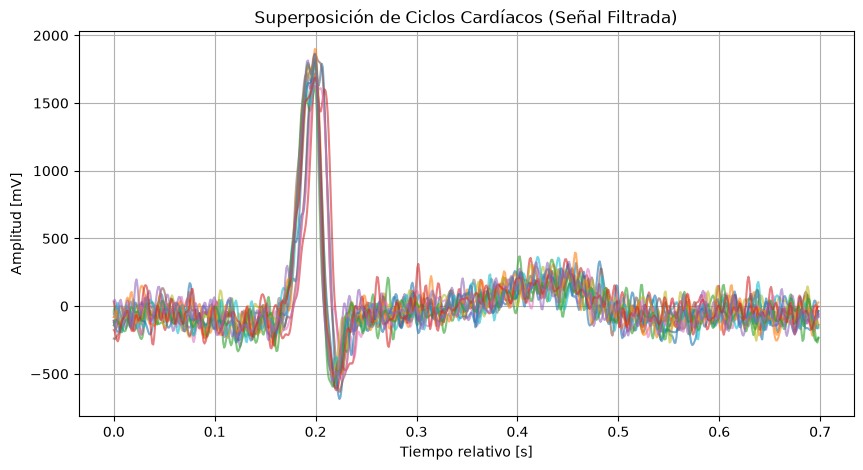

ESTADÍSTICOS POR CICLO (señal filtrada)
Ciclo 1: media = 16.306, varianza = 99784.30
Ciclo 2: media = 11.801, varianza = 96152.05
Ciclo 3: media = 3.171, varianza = 86270.40
Ciclo 4: media = 26.053, varianza = 87220.16
Ciclo 5: media = 21.239, varianza = 98051.72
Ciclo 6: media = 26.310, varianza = 100313.89
Ciclo 7: media = 18.281, varianza = 82777.99
Ciclo 8: media = 27.994, varianza = 94993.00
Ciclo 9: media = 42.538, varianza = 93216.28
Ciclo 10: media = 13.982, varianza = 86791.90
Ciclo 11: media = 12.025, varianza = 93065.93
Ciclo 12: media = 29.502, varianza = 101985.57
Ciclo 13: media = 10.193, varianza = 103649.35
Ciclo 14: media = 28.910, varianza = 87694.41
Ciclo 15: media = 21.841, varianza = 99487.79

Promedio de las medias: 20.677
Desviación estándar de las medias: 9.589
Promedio de las varianzas: 94096.98
Desviación estándar de las varianzas: 6361.66


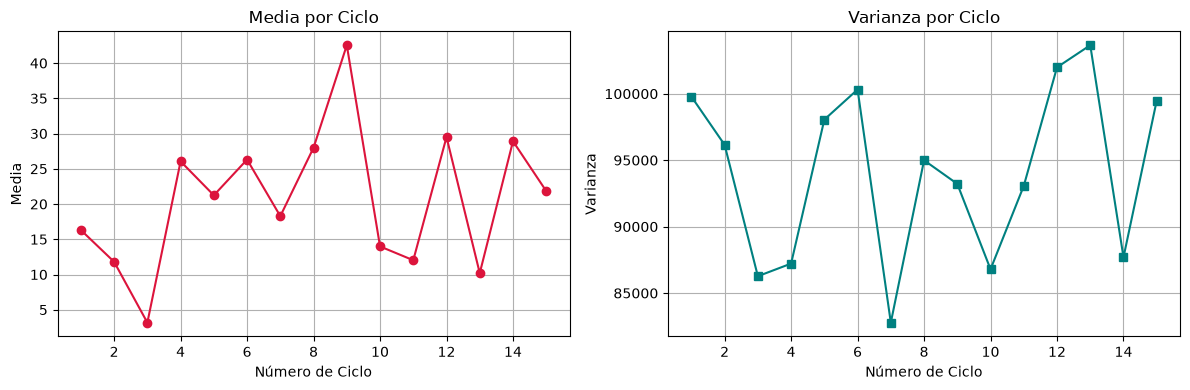

In [7]:
from scipy.signal import find_peaks

#Detección de picos R en la señal filtrada
picos_r, _ = find_peaks(filtrada, distance=int(fs * 0.6), height=np.max(filtrada) * 0.4)

#Definir ventana alrededor del pico R (0.2s antes y 0.5s después)
muestras_antes = int(0.2 * fs)
muestras_despues = int(0.5 * fs)

# Filtrar solo picos que permitan recortar la ventana completa ---
picos_validos = [p
    for p in picos_r
    if (p - muestras_antes >= 0) and (p + muestras_despues < len(filtrada))]

#Tomar hasta 15 picos que realmente tengan datos válidos
picos_15 = picos_validos[:15]

ciclos = []
medias = []
varianzas = []

plt.figure(figsize=(10, 5))

#Recortar los ciclos y calcular estadísticos
for i, pico in enumerate(picos_15):
  inicio = pico - muestras_antes
  fin = pico + muestras_despues

  ciclo = filtrada[inicio:fin]

  #Asegurar que el ciclo no esté vacío
  if len(ciclo) > 0:
    ciclos.append(ciclo)
    medias.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

    #Graficar cada ciclo superpuesto
    t_ciclo = np.arange(len(ciclo)) / fs
    plt.plot(t_ciclo, ciclo, alpha=0.6, label=f'Ciclo {i+1}' if i < 3 else '')

plt.title('Superposición de Ciclos Cardíacos (Señal Filtrada)')
plt.xlabel('Tiempo relativo [s]')
plt.ylabel('Amplitud [mV]')
plt.grid(True)
plt.show()

#Graficar comportamiento de Media y Varianza
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

#Usar len(medias) para evitar descalce de dimensiones
eje_x = range(1, len(medias) + 1)

# Imprimir estadísticos por ciclo
print("ESTADÍSTICOS POR CICLO (señal filtrada)")
for i, (m, v) in enumerate(zip(medias, varianzas), start=1):
    print(f"Ciclo {i}: media = {m:.3f}, varianza = {v:.2f}")

print(f"\nPromedio de las medias: {np.mean(medias):.3f}")
print(f"Desviación estándar de las medias: {np.std(medias):.3f}")
print(f"Promedio de las varianzas: {np.mean(varianzas):.2f}")
print(f"Desviación estándar de las varianzas: {np.std(varianzas):.2f}")

ax[0].plot(eje_x, medias, 'o-', color='crimson')
ax[0].set_title('Media por Ciclo')
ax[0].set_xlabel('Número de Ciclo')
ax[0].set_ylabel('Media')
ax[0].grid(True)

ax[1].plot(eje_x, varianzas, 's-', color='teal')
ax[1].set_title('Varianza por Ciclo')
ax[1].set_xlabel('Número de Ciclo')
ax[1].set_ylabel('Varianza')
ax[1].grid(True)

plt.tight_layout()
plt.show()


**Análisis:** Al graficar los 15 ciclos superpuestos, se observa que todos tienen una forma muy parecida y quedan prácticamente uno encima del otro, sin que ninguno se salga notablemente de los demás. Estadísticamente, las medias de los 15 ciclos se mantienen bajas y cercanas a cero (entre 3.17 y 42.54), sin mostrar una tendencia clara de subir o bajar a lo largo del tiempo. Las varianzas también se mantienen bastante parecidas entre ciclo y ciclo (entre 82,778 y 103,649), variando muy poco respecto a su promedio. Como ni el promedio ni la varianza cambian de forma importante o sistemática de un ciclo a otro, tanto la gráfica como los números sugieren que la señal filtrada se puede considerar aproximadamente estacionaria en este registro: sus características estadísticas básicas se mantienen relativamente estables en el tiempo, aunque con la variabilidad natural propia de un latido a otro.

5.Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico (prueba U de Mann-Whitney).

In [11]:
import numpy as np
from scipy import stats


def ciclo(señal, idx_inicio, Fs=1024, t_antes=0.2, t_posterior=0.4):
    v_antes = int(t_antes * Fs)
    v_despues = int(t_posterior * Fs)
    return señal[idx_inicio - v_antes : idx_inicio + v_despues]


c1 = ciclo(filtrada, picos_validos[1])
c2 = ciclo(filtrada, picos_validos[4])
c3 = ciclo(filtrada, picos_validos[9])
c4 = ciclo(filtrada, picos_validos[24])


def comparacion(cliclo_1, ciclo_2, nombre):
    print(f"{nombre} ")
    _, norm_1 = stats.shapiro(cliclo_1)
    _, norm_2 = stats.shapiro(ciclo_2)
    
  
    _, levene = stats.levene(cliclo_1, ciclo_2)
    
 
    normalidad = (norm_1 > 0.05) and (norm_2 > 0.05)
    homocedasticidad = (levene > 0.05)
    
    print(f"Normalidad p-val: A={norm_1:.4e}, B={norm_2:.4e}")
    print(f"Homocedasticidad p-val: {levene}")
    
  
    if normalidad and homocedasticidad:
        diferencia, valor_p = stats.ttest_ind(cliclo_1, ciclo_2, equal_var=True)
        peueba_t = "t-Student"
    else:
        diferencia, valor_p = stats.mannwhitneyu(cliclo_1, ciclo_2)
        peueba_t = "U de Mann-Whitney (No Paramétrica)"
        
    print(f"Resultado de prueba")
    print(f"Estadístico = {diferencia}, p-valor = {valor_p:}\n")


comparacion(c1, c2, "Comparación 1 (Ciclo 2 vs Ciclo 5)")
comparacion(c3, c4, "Comparación 2 (Ciclo 10 vs Ciclo 25)")

Comparación 1 (Ciclo 2 vs Ciclo 5) 
Normalidad p-val: A=8.3340e-36, B=6.7640e-36
Homocedasticidad p-val: 0.8616413526911758
Resultado de prueba
Estadístico = 179428.0, p-valor = 0.172509771396689

Comparación 2 (Ciclo 10 vs Ciclo 25) 
Normalidad p-val: A=2.2781e-35, B=1.4517e-36
Homocedasticidad p-val: 0.802872243723698
Resultado de prueba
Estadístico = 187987.0, p-valor = 0.9868710951436893



**Análisis :**
el analisis  con un nivel de significacia de 0.05 revela quye la señal ECG no cumple con el supuesto de normalidad en ninguno de los dos ciclos ya que en la prueba shaphiro-Wilk el valor p obtenido fue inferior a el nivel de significancia estimado (0.05) lo cual invalida la prueba t student y justifica el uso de la prueba no parametrica de Mann-whitney.Cuando se comparan los latidos mas cercanos (ciclo 2 vs ciclo 5 ) la prueba de levenne confirma que las varianzas son iguales, es decir el valor p fue de 0,8616 > 0.05 por lo cual existe una homocedasticidad y no se hallan diferencias muy significativas entre las distribuciuones p= 0.1725 demostrandoa si una estabilidad a corto plazo entre estos ciclos. Por otro lado entre los latidos mas distante (ciclo 10 vs ciclo 25) los cambios en el tiempo no generaron cambios en las varianzas p= 0.8028 exitiendo asi una homocedastividad con una diferencia de p=0.986 siendo un valor mayor a el nivel de significacia 0.986 > 0.05 por lo cual estos hallazgos nos muestran que la señal de electrocardiografia no tiene diferencias a nivel estadistico a la largo del tiempo.La señal de electrocardiografía filtrada conserva una elevada consistencia morfologica y es estacionaria tanto a nivel local como a nivel global.

6.Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal (Estacionariedad) 

In [18]:

from statsmodels.tsa.stattools import adfuller
result = adfuller(np.squeeze(filtrada))
print("ADF Statistic: %f" % result[0])
print("p-value: %f" % result[1])

ADF Statistic: -11.826890
p-value: 0.000000


**Analisis:**
la prueba de Dickey-fuller demuestra que debido a un valor p=0.000000 siendo menor que 0.05 y un estadistico de -11.82 permite rechazar la hipotesis nula acerca de una raiz unitaria. Por lo cual la señal filtrada es estacionaria en su media ya que esta oscila alrededor del cero.
El registro electrocardiografico es estacionario en su promedio debido al filtrado que se genero pero esta cambia de forma y amplitud, debido a que los latidos a lo largo del timpo cambian, esti debido a multiples factores situacionales o animicos.